# Analysis notebook

/tmp/ipykernel_54586/819585245.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


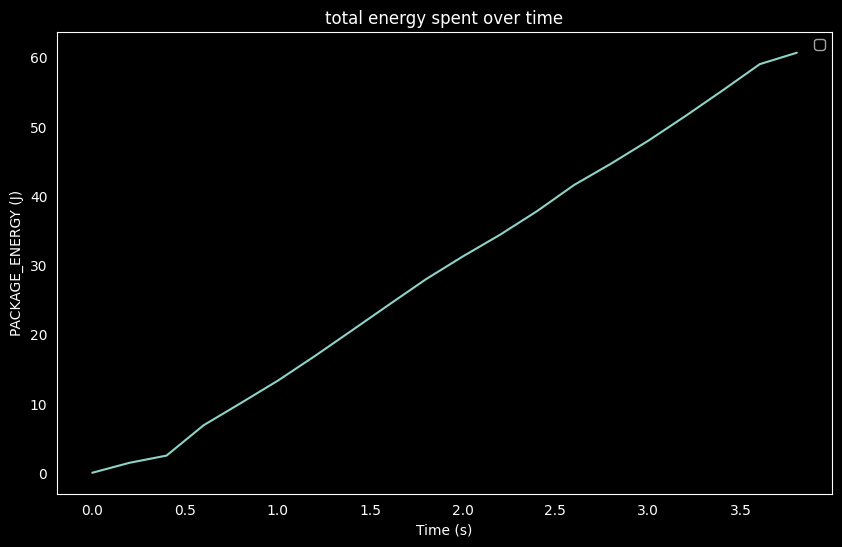

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

basepath = "data/out/energibridge_runs_all_languages/"
df = pd.read_csv(basepath + "python_measured_01.csv")
system_power_key = "PACKAGE_ENERGY (J)"
#system_power_key = "PP0_ENERGY (J)"     #cpu
#system_power_key = "PP1_ENERGY (J)"       #integrated graphics


plt.figure(figsize=(10, 6))
df['Time'] = df['Time'] - df['Time'].iloc[0]
df[system_power_key] = df[system_power_key] - df[system_power_key].iloc[0]
plt.plot(df['Time']/1000, df[system_power_key])

plt.xlabel('Time (s)')
plt.ylabel(system_power_key)
plt.title("total energy spent over time")
plt.legend()
plt.grid()
plt.show()

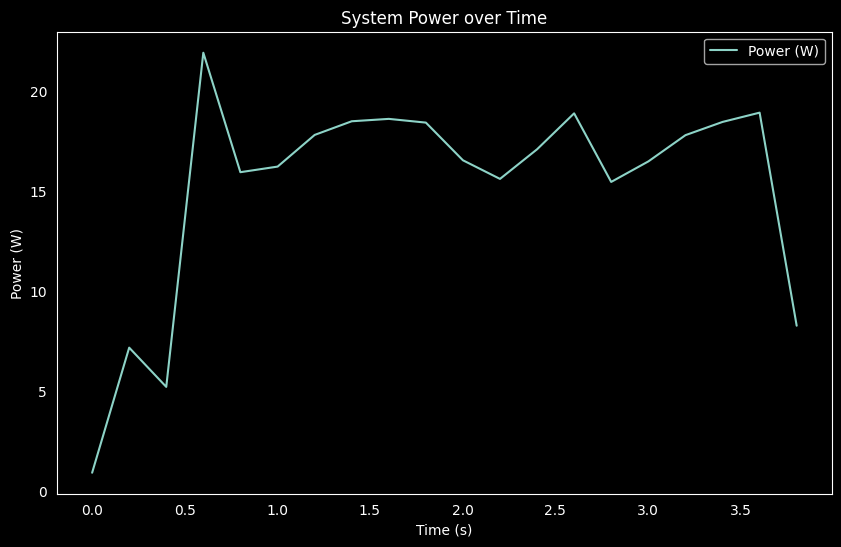

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

basepath = "data/out/energibridge_runs_all_languages/"
df = pd.read_csv(basepath + "python_measured_01.csv")

system_power_key = "PACKAGE_ENERGY (J)"
# system_power_key = "PP0_ENERGY (J)"   # CPU
# system_power_key = "PP1_ENERGY (J)"   # Integrated graphics

df['Time'] = df['Time'] - df['Time'].iloc[0]

df['Time_s'] = df['Time'] / 1000

# Compute differences
dE = df[system_power_key].diff()       # Joules
dt = df['Time_s'].diff()               # Seconds

df['Power_W'] = dE / dt

df = df.dropna()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df['Time_s'], df['Power_W'], label='Power (W)')

plt.xlabel('Time (s)')
plt.ylabel('Power (W)')
plt.title('System Power over Time')
plt.legend()
plt.grid()
plt.show()

In [13]:
import pandas as pd
import numpy as np
import os

basepath = "data/out/energibridge_runs_all_languages"
system_energy_key = "PACKAGE_ENERGY (J)"
# system_energy_key = "PP0_ENERGY (J)"
# system_energy_key = "PP1_ENERGY (J)"



def read_files(name):
    total_energies = []
    for i in range(20):
        file_path = os.path.join(basepath, f"{name}_measured_0{i+1}.csv")
        if i >= 9:
            file_path = os.path.join(basepath, f"{name}_measured_{i+1}.csv")
        df = pd.read_csv(file_path)

        # Total energy consumed during the run
        energy_total = df[system_energy_key].iloc[-1] - df[system_energy_key].iloc[0]
        total_energies.append(energy_total)

    return total_energies

python_energies = read_files("python")
go_energies = read_files("go")
java_energies = read_files("java")
rust_energies = read_files("rust")


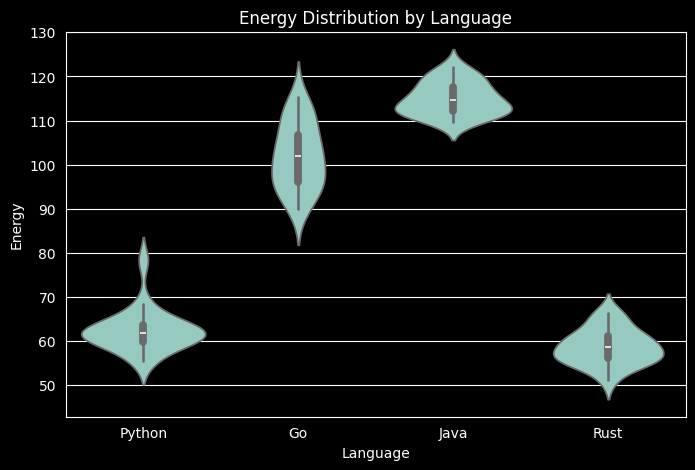

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

python_energies = read_files("python")
go_energies = read_files("go")
java_energies = read_files("java")
rust_energies = read_files("rust")

# Build long-format data
data = pd.DataFrame({
    "Energy": (
        python_energies
        + go_energies
        + java_energies
        + rust_energies
    ),
    "Language": (
        ["Python"] * len(python_energies)
        + ["Go"] * len(go_energies)
        + ["Java"] * len(java_energies)
        + ["Rust"] * len(rust_energies)
    )
})

# Plot
plt.figure(figsize=(8, 5))
sns.violinplot(x="Language", y="Energy", data=data, inner="box")
plt.title("Energy Distribution by Language")
plt.show()

19
20
20
20


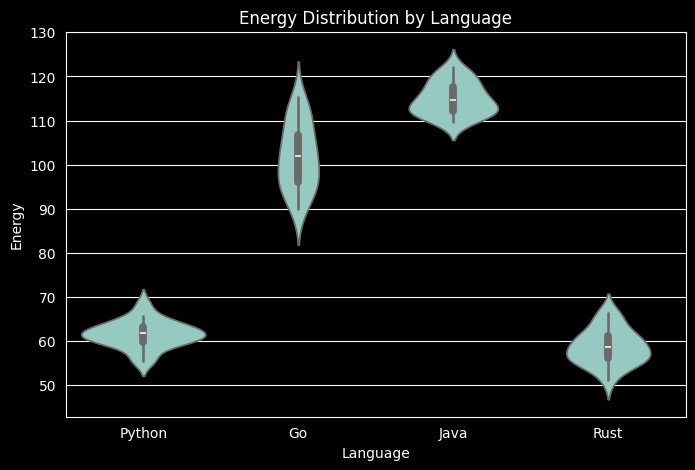

In [19]:




def remove_z_outliers(group, threshold=3):
    mean = group.mean()
    std = group.std()
    z_scores = (group - mean) / std
    return group[np.abs(z_scores) <= threshold]

z_python = remove_z_outliers(np.array(python_energies))
z_go = remove_z_outliers(np.array(go_energies))
z_java = remove_z_outliers(np.array(java_energies))
z_rust = remove_z_outliers(np.array(rust_energies))
print(len(z_python))
print(len(z_java))
print(len(z_java))
print(len(z_rust))



data = pd.DataFrame({
    "Energy": np.concatenate([z_python, z_go, z_java, z_rust]),
    "Language": (
        ["Python"] * len(z_python) +
        ["Go"] * len(z_go) +
        ["Java"] * len(z_java) +
        ["Rust"] * len(z_rust)
    )
})

# Plot
plt.figure(figsize=(8, 5))
sns.violinplot(x="Language", y="Energy", data=data, inner="box")
plt.title("Energy Distribution by Language")
plt.show()

In [21]:
from scipy.stats import shapiro
import numpy as np

def shapiro_test(name, data):
    data = np.array(data)
    stat, p = shapiro(data)
    print(f"{name}: W={stat:.4f}, p={p:.4f} -> ", end="")
    if p < 0.05:
        print("Not normal")
    else:
        print("Normal (fail to reject H0)")

shapiro_test("Python", z_python)
shapiro_test("Go", z_go)
shapiro_test("Java", z_java)
shapiro_test("Rust", z_rust)

Python: W=0.9732, p=0.8379 -> Normal (fail to reject H0)
Go: W=0.9608, p=0.5607 -> Normal (fail to reject H0)
Java: W=0.9458, p=0.3081 -> Normal (fail to reject H0)
Rust: W=0.9711, p=0.7775 -> Normal (fail to reject H0)


Two-sided parametric test Welch’s t-test

In [22]:
from scipy.stats import ttest_ind
import numpy as np

def welch_test(name1, data1, name2, data2):
    data1 = np.array(data1)
    data2 = np.array(data2)

    stat, p = ttest_ind(data1, data2, equal_var=False)

    print(f"{name1} vs {name2}: t={stat:.4f}, p={p:.4f} -> ", end="")
    if p < 0.05:
        print("Significant difference")
    else:
        print("No significant difference")

welch_test("Python", z_python, "Go", z_go)
welch_test("Python", z_python, "Java", z_java)
welch_test("Python", z_python, "Rust", z_rust)

welch_test("Go", z_go, "Java", z_java)
welch_test("Go", z_go, "Rust", z_rust)

welch_test("Java", z_java, "Rust", z_rust)

Python vs Go: t=-22.4240, p=0.0000 -> Significant difference
Python vs Java: t=-49.5417, p=0.0000 -> Significant difference
Python vs Rust: t=2.5631, p=0.0148 -> Significant difference
Go vs Java: t=-7.0707, p=0.0000 -> Significant difference
Go vs Rust: t=22.9686, p=0.0000 -> Significant difference
Java vs Rust: t=46.4587, p=0.0000 -> Significant difference
